# B3b Defense – 05 SHAP Analysis

**Objective:** Explain the trained XGBoost model using SHAP values.
Generate a beeswarm summary plot, a feature importance bar chart, and a waterfall plot
for the last training observation.

## Note on StandardScaler

`StandardScaler` is applied **only for SHAP visualization** (beeswarm plot) so that
feature magnitudes are comparable on the color axis. The XGBoost model itself was trained
on **unscaled** data, and SHAP values are computed on unscaled data as well.
XGBoost is scale-invariant; scaling is purely a display convenience here.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

C:\Users\gdenn\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODELS_DIR     = '../models/'
DATA_PROCESSED = '../data/processed/'

# Load model and feature matrix
model = joblib.load(MODELS_DIR + 'xgboost_defense_market.pkl')

df = pd.read_csv(DATA_PROCESSED + 'defense_feature_matrix.csv', parse_dates=['date'], index_col='date')

print(f'Model loaded from: {MODELS_DIR}xgboost_defense_market.pkl')
print(f'Feature matrix shape: {df.shape}')

Model loaded from: ../models/xgboost_defense_market.pkl
Feature matrix shape: (305, 32)


In [3]:
# Define feature columns (all except target)
feature_cols = [col for col in df.columns if col != 'ADEFNO']
X = df[feature_cols]

# Apply StandardScaler for visualization only — model was trained on unscaled data
scaler  = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

print('StandardScaler fitted on X (for visualization only).')
print(f'X shape: {X.shape}  |  X_scaled shape: {X_scaled.shape}')

StandardScaler fitted on X (for visualization only).
X shape: (305, 31)  |  X_scaled shape: (305, 31)


In [4]:
# Compute SHAP values
# - shap_values: computed on unscaled X (model expects unscaled input)
# - shap_values_scaled: computed on X_scaled for beeswarm color axis
explainer = shap.TreeExplainer(model)

shap_values        = explainer.shap_values(X)
shap_values_scaled = explainer.shap_values(X_scaled)

print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values shape: (305, 31)


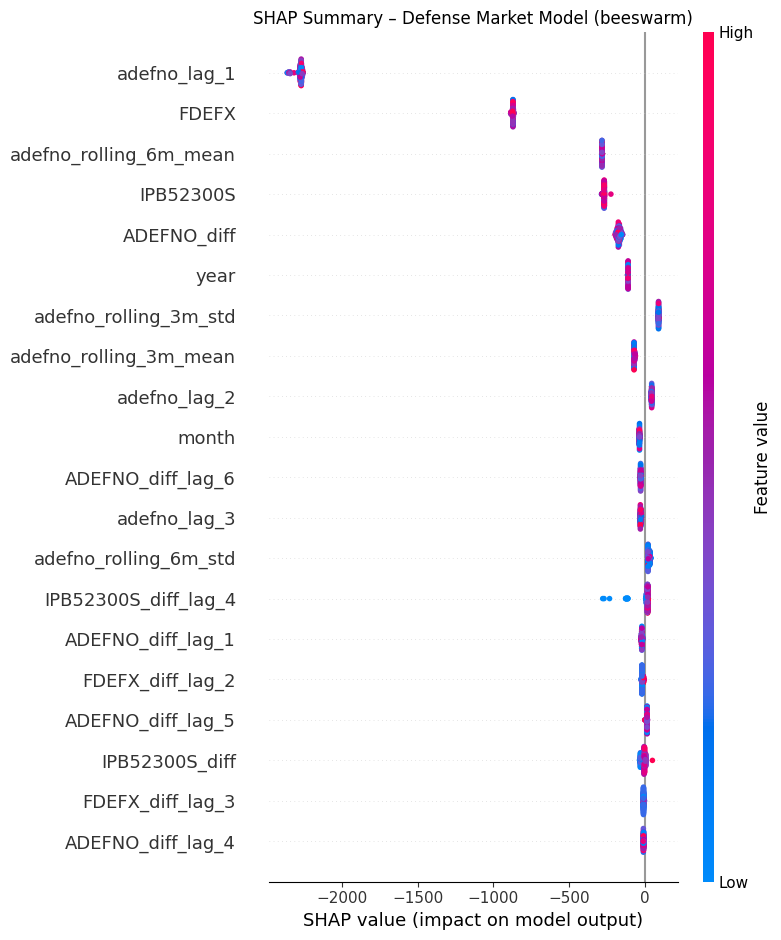

Saved: shap_defense_summary.png


In [5]:
# SHAP Summary Plot (beeswarm) — uses scaled X for color axis
shap.summary_plot(shap_values_scaled, X_scaled, show=False)
plt.title('SHAP Summary – Defense Market Model (beeswarm)')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_summary.png')

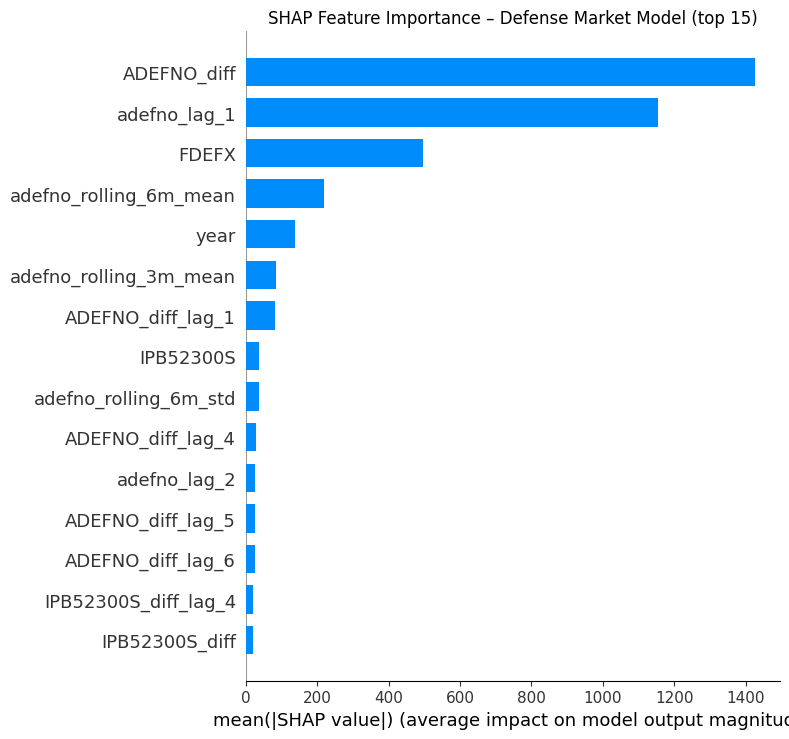

Saved: shap_defense_importance.png


In [6]:
# SHAP Importance Bar Chart (top 15 features) — uses unscaled X
shap.summary_plot(shap_values, X, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance – Defense Market Model (top 15)')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_importance.png')

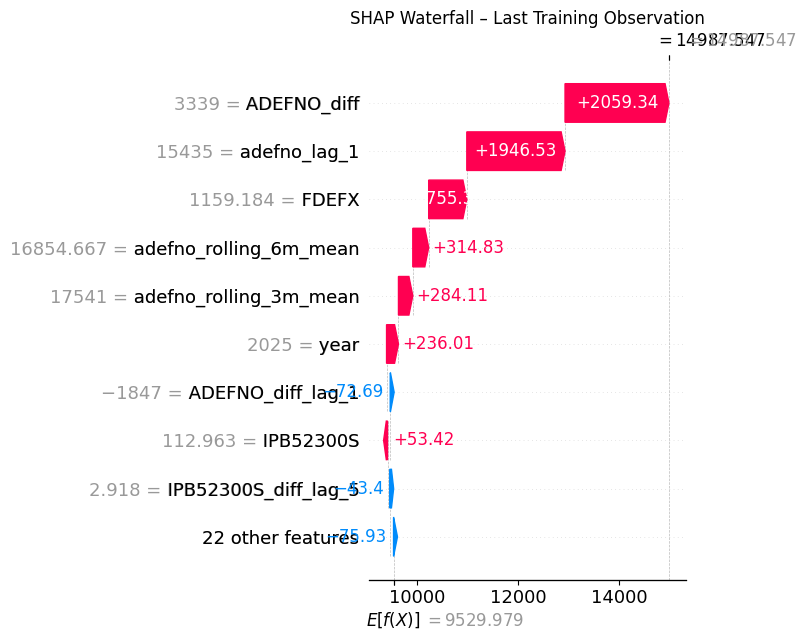

Saved: shap_defense_waterfall.png


In [7]:
# SHAP Waterfall for last training observation
explanation = shap.Explanation(
    values        = shap_values,
    base_values   = explainer.expected_value,
    data          = X.values,
    feature_names = feature_cols
)

shap.plots.waterfall(explanation[-1], show=False)
plt.title('SHAP Waterfall – Last Training Observation')
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_defense_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: shap_defense_waterfall.png')

In [8]:
print('SHAP analysis complete. Plots saved to', MODELS_DIR)

SHAP analysis complete. Plots saved to ../models/


## SHAP Results – Interpretation

### Feature Importance Ranking (Bar Chart)

| Rank | Feature | Meaning |
|------|---------|---------|
| 1 | `ADEFNO_diff` | Current month-over-month change in market volume |
| 2 | `adefno_lag_1` | ADEFNO level of the previous month |
| 3 | `FDEFX` | Realized federal defense expenditures (level) |
| 4 | `adefno_rolling_6m_mean` | 6-month rolling mean of ADEFNO |
| 5 | `year` | Long-run trend |
| 6 | `adefno_rolling_3m_mean` | 3-month rolling mean of ADEFNO |
| 7 | `ADEFNO_diff_lag_1` | Prior month change in ADEFNO |
| 8 | `IPB52300S` | Defense industrial production index (level) |

---

### Direction and Distribution (Beeswarm)

`adefno_lag_1` ranks first in the beeswarm while `ADEFNO_diff` leads the bar chart.
This is not a contradiction — the bar chart reports the mean of absolute SHAP values,
while the beeswarm shows the full distribution. `ADEFNO_diff` produces very high individual
contributions during extreme market movements but is less consistently dominant across all
305 observations than the AR lag.

Key directional findings from the beeswarm color axis (red = high feature value, blue = low):

- **`adefno_lag_1` (high → positive SHAP):** A high prior month level raises the forecast —
  strong autoregressive momentum signal. The model extrapolates persistence in ordering behavior,
  consistent with multi-month defense procurement programs.

- **`FDEFX` (high → negative SHAP):** High realized expenditures slightly suppress the forecast.
  Likely a mean-reversion dynamic: periods of elevated actual spending are followed by a
  normalization in new orders.

- **`year` (high → positive SHAP):** More recent years produce higher forecasts — the model
  has learned the structural upward trend in the defense sector post-2000. This trend
  will be extrapolated into the 2026 forecast in Notebook 06.

---

### Waterfall – Last Training Observation (Dec 2025)

- **Base value E[f(X)]:** ~9,530 USD mn
- **Final prediction:** ~14,988 USD mn
- **Net uplift above base:** +5,458 USD mn

| Feature | Value | SHAP contribution |
|---------|-------|-------------------|
| `ADEFNO_diff` | 3,339 | **+2,059 USD mn** |
| `adefno_lag_1` | 15,435 | **+1,947 USD mn** |
| `FDEFX` | 1,159 | **+755 USD mn** |
| `adefno_rolling_6m_mean` | 16,855 | +315 USD mn |
| `adefno_rolling_3m_mean` | 17,541 | +284 USD mn |
| `year` | 2025 | +236 USD mn |
| `ADEFNO_diff_lag_3` | −1,847 | −169 USD mn |
| `IPB52300S` | 112.96 | +53 USD mn |
| 22 other features | — | +93 USD mn |

---

### Overall Conclusions

**The model is strongly autoregressive.** `ADEFNO_diff` and `adefno_lag_1` together account
for over 4,000 USD mn of the uplift in December 2025. This is methodologically sound:
defense orders exhibit strong momentum because procurement programs run across multiple months.

**FDEFX delivers a substantial contribution** (rank 3 in the bar chart), validating its
inclusion as the third data source. Replacing the general-purpose DGORDER/INDPRO series
with defense-specific realized expenditures was the right design choice — FDEFX is a more
targeted demand proxy for this sector.

**`IPB52300S` (production index)** is present but secondary — it influences the forecast
mainly when production levels deviate from their typical range rather than on a month-to-month basis.

**The `year` feature** confirms that the model has explicitly learned the long-run upward
trend in defense sector activity. For the 2026 forecast (Notebook 06), this means the trend
component will be carried forward, which is consistent with the carry-forward baseline approach.